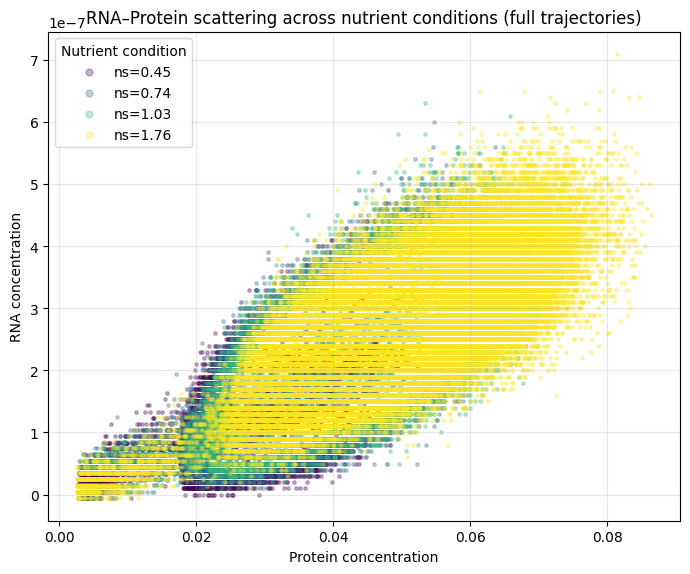

In [4]:
# === RNA–Protein scatter across full trajectories ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def extract_rna_protein(df):
    """Return RNA and Protein for entire trajectory."""
    RNA = np.zeros(len(df))
    PROT = np.zeros(len(df))
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].values/1e8     
    return RNA, PROT

# --- Hard-coded nutrient mapping ---
files_with_ns = [
    ("Data/ns045.arrow", 0.45),
    ("Data/ns074.arrow", 0.74),
    ("Data/ns103.arrow", 1.03),
    ("Data/ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))

plt.figure(figsize=(7, 6))
for (filename, ns), color in zip(files_with_ns, colors):
    df = read_arrow(filename)
    RNA, PROT = extract_rna_protein(df)

    plt.scatter(PROT, RNA, s=6, alpha=0.3, color=color, label=f"ns={ns:.2f}")


plt.xlabel("Protein concentration")
plt.ylabel("RNA concentration")
plt.title("RNA–Protein scattering across nutrient conditions (full trajectories)")
plt.legend(title="Nutrient condition", markerscale=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


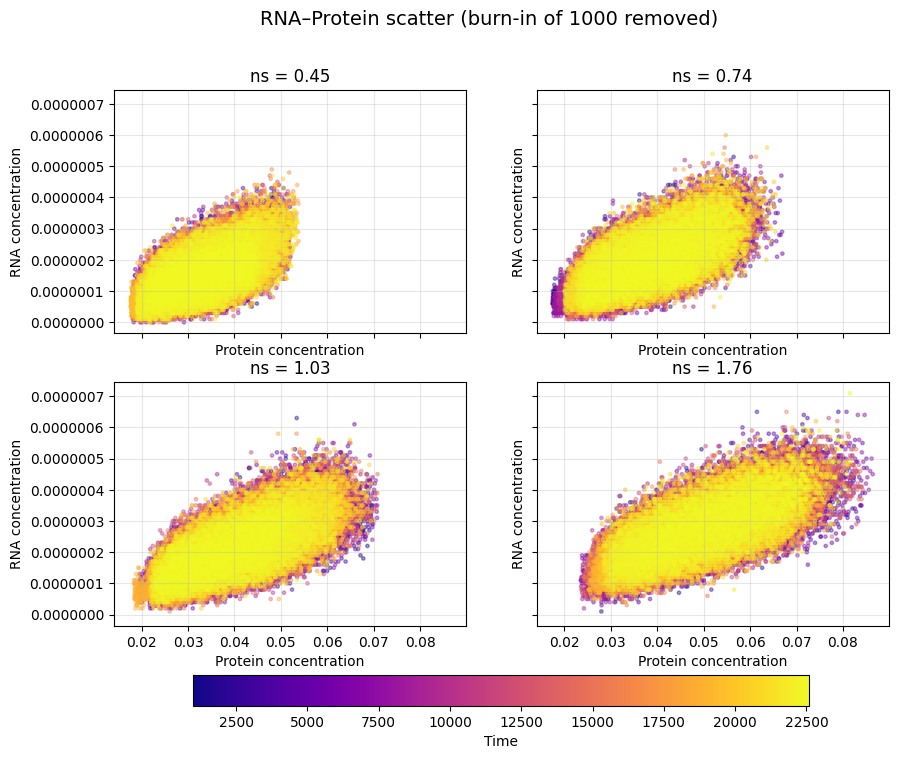

-0.008842091343361865
-0.013645070838910735


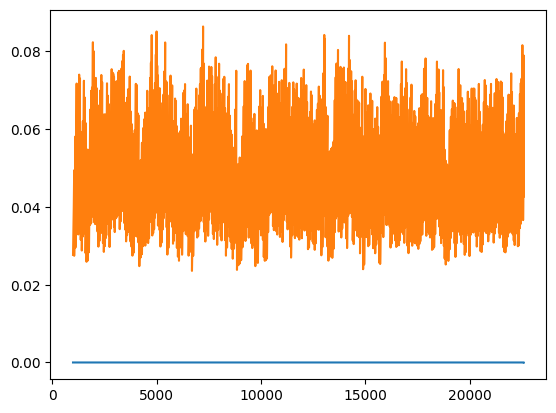

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def extract_rna_protein(df):
    """Compute total RNA and Protein (free RNA definition)."""
    RNA = np.zeros(len(df))
    PROT = np.zeros(len(df))
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].values/1e8
    return RNA, PROT

# --- Config ---
files_with_ns = [
    ("Data/ns045.arrow", 0.45),
    ("Data/ns074.arrow", 0.74),
    ("Data/ns103.arrow", 1.03),
    ("Data/ns176.arrow", 1.76),
]

burn_in_time = 1000     
cmap = plt.cm.plasma    

# --- Create one axes per nutrient condition ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for (filename, ns), ax in zip(files_with_ns, axes):
    df = read_arrow(filename)

    # --- Drop burn-in points ---
    if "timestamp" not in df.columns:
        raise ValueError(f"File {filename} has no 't' column for time-gradient coloring.")

    df = df[df["timestamp"] >= burn_in_time].reset_index(drop=True)

    # --- Extract concentrations ---
    RNA, PROT = extract_rna_protein(df)
    T = df["timestamp"].values

    # --- Normalize time to [0,1] for colormap ---
    T_norm = (T - T.min()) / (T.max() - T.min() + 1e-12)
    colors = cmap(T_norm)

    # --- Scatter plot with time gradient ---
    sc = ax.scatter(PROT, RNA, s=6, alpha=0.4, c=colors)

    # Aesthetics
    ax.set_title(f"ns = {ns:.2f}")
    ax.set_xlabel("Protein concentration")
    ax.set_ylabel("RNA concentration")
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')
# Add a shared colourbar for time
norm = plt.Normalize(vmin=burn_in_time, vmax=df["timestamp"].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("Time")


# Main title
fig.suptitle(
    f"RNA–Protein scatter (burn-in of {burn_in_time} removed)",
    fontsize=14
)



plt.show()
plt.plot(df["timestamp"], RNA)
plt.plot(df["timestamp"], PROT)
print(np.corrcoef(df["timestamp"], RNA)[0,1])
print(np.corrcoef(df["timestamp"], PROT)[0,1])


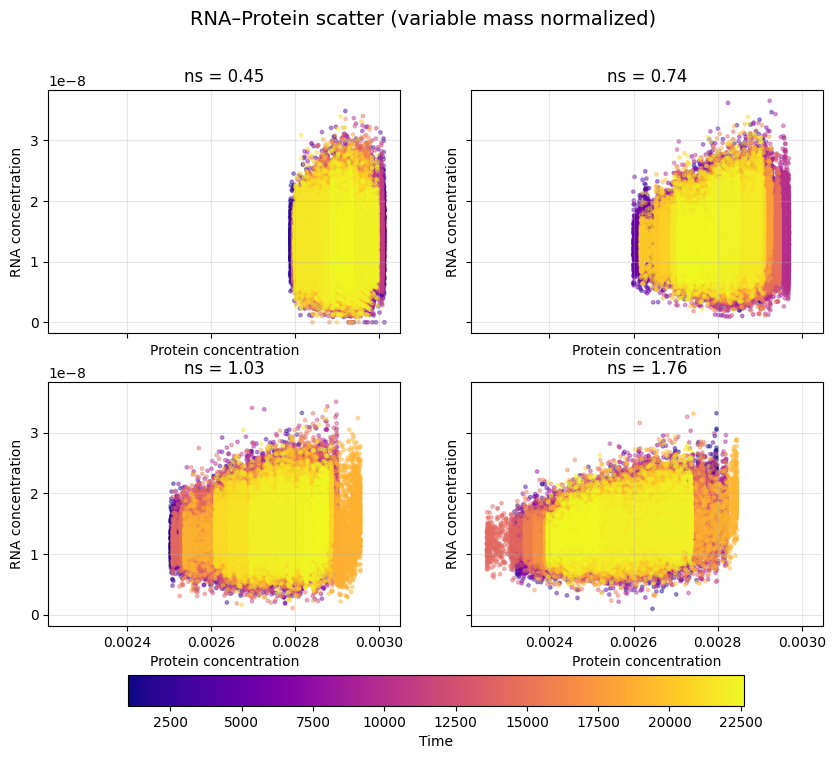

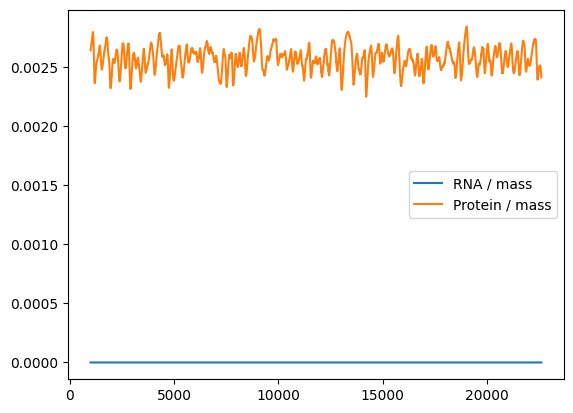

corr(time, RNA)  = 0.006262008602844444
corr(time, PROT) = 0.01420252644078069


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ===============================================================
# Constants (IDENTICAL to your Scott/Raman analysis)
# ===============================================================
NR = 7549.0
NX = 300.0
BURN_IN = 1000.0

# ===============================================================
# I/O
# ===============================================================
def read_arrow(filename):
    with pa.memory_map(filename, "r") as source:
        return ipc.open_file(source).read_all().to_pandas()

# ===============================================================
# Variable total mass (AUTHORITATIVE)
# ===============================================================
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    total_mass = ribo_mass + non_ribo
    return total_mass

# ===============================================================
# RNA–Protein extraction (BIOLOGY UNCHANGED)
# ===============================================================
def extract_rna_protein_mass_normalized(df):
    """
    RNA  = free mRNA counts
    PROT = free protein counts
    Both normalized by variable total mass(t)
    """

    RNA = np.zeros(len(df))
    PROT = np.zeros(len(df))

    # --- free mRNA ---
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
        if col in df.columns:
            RNA += df[col].to_numpy()

    # --- free protein ---
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].to_numpy()

    # --- variable mass ---
    total_mass = compute_mass(df)

    RNA /= total_mass
    PROT /= total_mass

    return RNA, PROT

# ===============================================================
# Plot configuration
# ===============================================================
files_with_ns = [
    ("Data/ns045.arrow", 0.45),
    ("Data/ns074.arrow", 0.74),
    ("Data/ns103.arrow", 1.03),
    ("Data/ns176.arrow", 1.76),
]

cmap = plt.cm.plasma

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

# ===============================================================
# Main loop
# ===============================================================
for (filename, ns), ax in zip(files_with_ns, axes):

    df = read_arrow(filename)

    if "timestamp" not in df.columns:
        raise ValueError(f"{filename} has no timestamp column")

    df = df[df["timestamp"] >= BURN_IN].reset_index(drop=True)

    RNA, PROT = extract_rna_protein_mass_normalized(df)
    T = df["timestamp"].to_numpy()

    # time colour
    T_norm = (T - T.min()) / (T.max() - T.min() + 1e-12)
    colors = cmap(T_norm)

    ax.scatter(PROT, RNA, s=6, alpha=0.4, c=colors)
    ax.set_title(f"ns = {ns:.2f}")
    ax.set_xlabel("Protein concentration")
    ax.set_ylabel("RNA concentration")
    ax.grid(alpha=0.3)

# ===============================================================
# Shared colourbar
# ===============================================================
norm = plt.Normalize(vmin=BURN_IN, vmax=T.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, orientation="horizontal",
                    fraction=0.05, pad=0.08)
cbar.set_label("Time")

fig.suptitle("RNA–Protein scatter (variable mass normalized)", fontsize=14)
plt.show()

# ===============================================================
# Diagnostics
# ===============================================================
plt.figure()
plt.plot(T, RNA, label="RNA / mass")
plt.plot(T, PROT, label="Protein / mass")
plt.legend()
plt.show()

print("corr(time, RNA)  =", np.corrcoef(T, RNA)[0,1])
print("corr(time, PROT) =", np.corrcoef(T, PROT)[0,1])


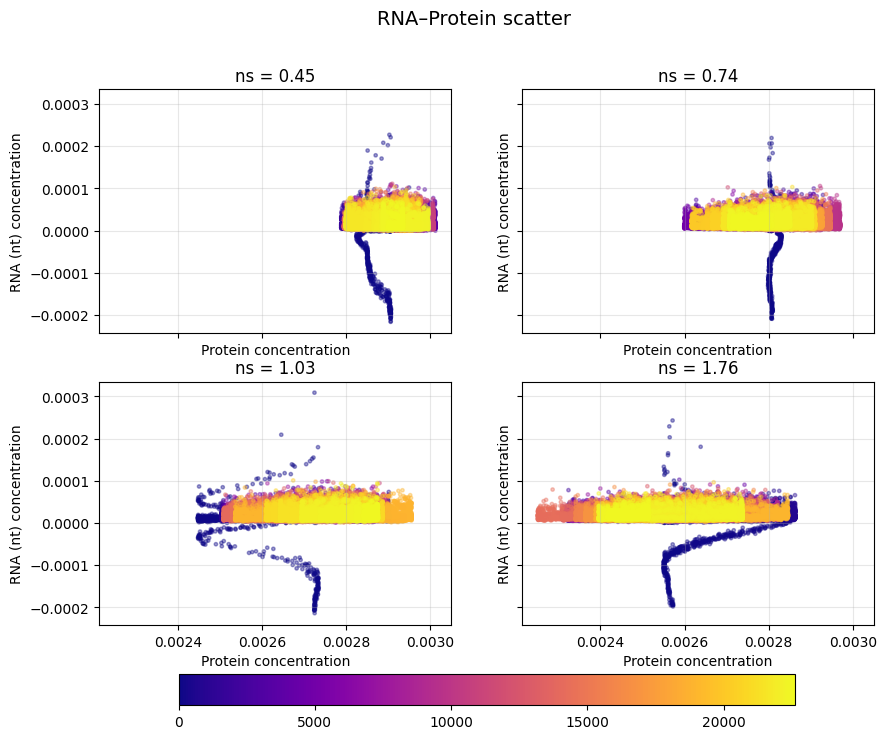

corr(time, RNA)  = 0.047850508606062846
corr(time, PROT) = -0.09075305392896152


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ===============================================================
# Constants (AUTHORITATIVE)
# ===============================================================
NR = 7549.0
NX = 300.0
BURN_IN = 0 #1000.0

MRNA_LENGTHS_AA = {
    "mm": NX,
    "mt": NX,
    "mq": NX,
    "mr": NR,
}

# ===============================================================
# I/O
# ===============================================================
def read_arrow(filename):
    with pa.memory_map(filename, "r") as source:
        return ipc.open_file(source).read_all().to_pandas()

# ===============================================================
# Variable total mass (unchanged)
# ===============================================================
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo

# ===============================================================
# RNA (NUCLEOTIDE-BASED) + Protein proxy
# ===============================================================
def extract_rna_nt_protein_mass_normalized(df):
    """
    RNA  = free mRNA in nucleotides
    PROT = free protein proxy (counts)
    Both normalized by variable total mass(t)
    """

    # --- RNA in nucleotides ---
    RNA_nt = np.zeros(len(df))

    for gene, aa_len in MRNA_LENGTHS_AA.items():
        col = f"{gene}(t)"
        if col in df.columns:
            RNA_nt += df[col].to_numpy() * (3 * aa_len)

    # --- free protein proxy ---
    PROT = np.zeros(len(df))
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].to_numpy()

    # --- normalize by variable mass ---
    total_mass = compute_mass(df)

    RNA = RNA_nt / total_mass
    PROT = PROT / total_mass

    return RNA, PROT

# ===============================================================
# Plot configuration
# ===============================================================
files_with_ns = [
    ("Data/ns045.arrow", 0.45),
    ("Data/ns074.arrow", 0.74),
    ("Data/ns103.arrow", 1.03),
    ("Data/ns176.arrow", 1.76),
]

cmap = plt.cm.plasma

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

# ===============================================================
# Main loop
# ===============================================================
for (filename, ns), ax in zip(files_with_ns, axes):

    df = read_arrow(filename)
    df = df[df["timestamp"] >= BURN_IN].reset_index(drop=True)

    RNA, PROT = extract_rna_nt_protein_mass_normalized(df)
    T = df["timestamp"].to_numpy()

    T_norm = (T - T.min()) / (T.max() - T.min() + 1e-12)
    colors = cmap(T_norm)

    ax.scatter(PROT, RNA, s=6, alpha=0.4, c=colors)
    ax.set_title(f"ns = {ns:.2f}")
    ax.set_xlabel("Protein concentration")
    ax.set_ylabel("RNA (nt) concentration")
    ax.grid(alpha=0.3)

# ===============================================================
# Colourbar
# ===============================================================
norm = plt.Normalize(vmin=BURN_IN, vmax=T.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=axes, orientation="horizontal",
             fraction=0.05, pad=0.08)

fig.suptitle("RNA–Protein scatter",
             fontsize=14)

plt.show()


print("corr(time, RNA)  =", np.corrcoef(T, RNA)[0,1])
print("corr(time, PROT) =", np.corrcoef(T, PROT)[0,1])


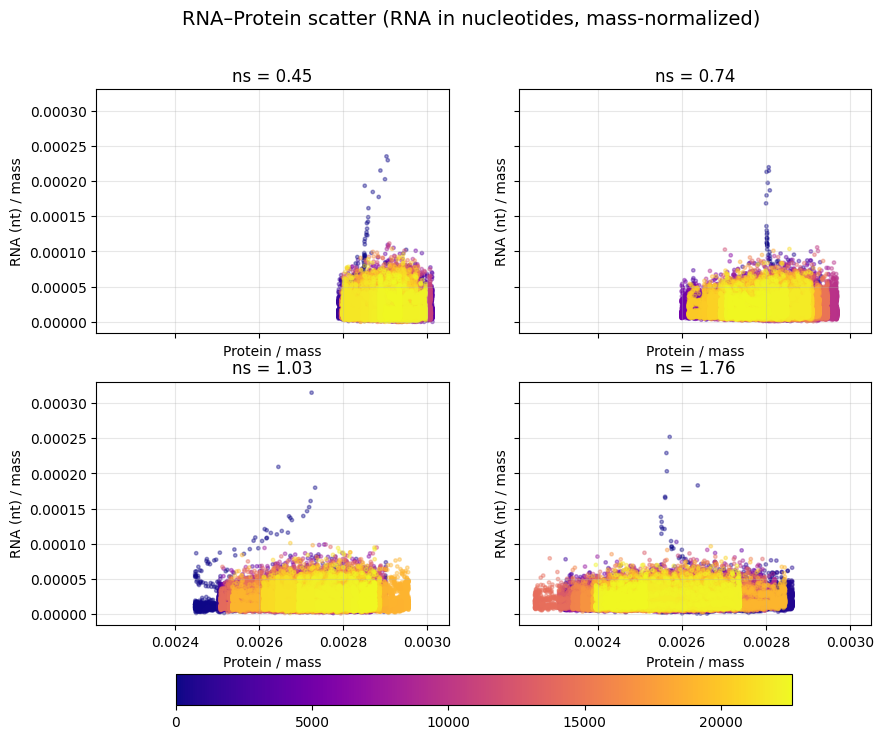

corr(time, RNA)  = 0.007833314436787059
corr(time, PROT) = -0.09075305392896152


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ===============================================================
# Constants (AUTHORITATIVE)
# ===============================================================
NR = 7549.0
NX = 300.0
BURN_IN = 0  # no burn-in

MRNA_LENGTHS_AA = {
    "mm": NX,
    "mt": NX,
    "mq": NX,
    "mr": NR,
}

RNA_COLS = ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]

# ===============================================================
# I/O
# ===============================================================
def read_arrow(filename):
    with pa.memory_map(filename, "r") as source:
        return ipc.open_file(source).read_all().to_pandas()

# ===============================================================
# Variable total mass (unchanged)
# ===============================================================
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo

# ===============================================================
# RNA (NUCLEOTIDE-BASED) + Protein proxy
# ===============================================================
def extract_rna_nt_protein_mass_normalized(df):
    """
    RNA  = free mRNA in nucleotides (clipped at 0)
    PROT = free protein proxy (counts)
    Both normalized by variable total mass(t)
    """

    # --- RNA in nucleotides ---
    RNA_nt = np.zeros(len(df))

    for gene, aa_len in MRNA_LENGTHS_AA.items():
        col = f"{gene}(t)"
        if col in df.columns:
            RNA_nt += df[col].to_numpy() * (3 * aa_len)

    # --- free protein proxy ---
    PROT = np.zeros(len(df))
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].to_numpy()

    # --- normalize by variable mass ---
    total_mass = compute_mass(df)

    RNA = RNA_nt / total_mass
    PROT = PROT / total_mass

    return RNA, PROT

# ===============================================================
# Plot configuration
# ===============================================================
files_with_ns = [
    ("Data/ns045.arrow", 0.45),
    ("Data/ns074.arrow", 0.74),
    ("Data/ns103.arrow", 1.03),
    ("Data/ns176.arrow", 1.76),
]

cmap = plt.cm.plasma

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

# ===============================================================
# Main loop
# ===============================================================
for (filename, ns), ax in zip(files_with_ns, axes):

    df = read_arrow(filename)
    df = df[df["timestamp"] >= BURN_IN].reset_index(drop=True)

    # -----------------------------------------------------------
    # FIX 1: clip RNA at zero (numerical undershoot correction)
    # -----------------------------------------------------------
    for c in RNA_COLS:
        if c in df.columns:
            df[c] = np.maximum(df[c].to_numpy(), 0.0)

    RNA, PROT = extract_rna_nt_protein_mass_normalized(df)
    T = df["timestamp"].to_numpy()

    T_norm = (T - T.min()) / (T.max() - T.min() + 1e-12)
    colors = cmap(T_norm)

    ax.scatter(PROT, RNA, s=6, alpha=0.4, c=colors)
    ax.set_title(f"ns = {ns:.2f}")
    ax.set_xlabel("Protein / mass")
    ax.set_ylabel("RNA (nt) / mass")
    ax.grid(alpha=0.3)

# ===============================================================
# Colourbar
# ===============================================================
norm = plt.Normalize(vmin=BURN_IN, vmax=T.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=axes, orientation="horizontal",
             fraction=0.05, pad=0.08)

fig.suptitle("RNA–Protein scatter (RNA in nucleotides, mass-normalized)",
             fontsize=14)

plt.show()

print("corr(time, RNA)  =", np.corrcoef(T, RNA)[0,1])
print("corr(time, PROT) =", np.corrcoef(T, PROT)[0,1])


In [16]:
rna_cols = ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]
prot_cols = ["r(t)", "et(t)", "em(t)", "q(t)"]
mass_cols = ["r(t)","rmm(t)","rmt(t)","rmq(t)","rmr(t)","zmm(t)","zmt(t)","zmq(t)","zmr(t)","q(t)","et(t)","em(t)"]

total_mass = compute_mass(df)  # your NR/NX mass definition
RNA_nt = np.zeros(len(df))
for gene, aa_len in MRNA_LENGTHS_AA.items():
    col = f"{gene}(t)"
    if col in df.columns:
        RNA_nt += df[col].to_numpy() * (3 * aa_len)

print("Min total_mass:", np.min(total_mass))
print("Min RNA_nt:", np.min(RNA_nt))

for c in rna_cols:
    if c in df.columns:
        vmin = df[c].min()
        if vmin < 0:
            print("NEG RNA col:", c, "min=", vmin)

# where do negatives happen?
neg_idx = np.where((RNA_nt < 0) | (total_mass <= 0))[0]
print("Bad rows:", len(neg_idx))
if len(neg_idx) > 0:
    i = neg_idx[0]
    print("Example bad row timestamp:", df["timestamp"].iloc[i])
    print(df.loc[df.index[i], rna_cols + mass_cols])


Min total_mass: 100000000.00000007
Min RNA_nt: -21622.789051742133
NEG RNA col: mr(t) min= -0.9708862603781694
NEG RNA col: mt(t) min= -0.9923082344920566
NEG RNA col: mm(t) min= -0.992308234492054
NEG RNA col: mq(t) min= -0.6099701009689245
Bad rows: 416
Example bad row timestamp: 0.16666666666666666
mr(t)         -0.970886
mt(t)          0.007692
mm(t)          0.007692
mq(t)          2.390030
r(t)        3000.696122
rmm(t)         0.634671
rmt(t)         0.634671
rmq(t)       112.695530
rmr(t)        38.023488
zmm(t)         0.000000
zmt(t)         0.000000
zmq(t)         0.000000
zmr(t)         0.000000
q(t)      252271.549966
et(t)       1395.928112
em(t)       1396.928112
Name: 1, dtype: float64
